**Problem Statement**

Electric vehicle (EV) buyers often want to know: "How far can an electric vehicle travel on a single charge based on its battery capacity?"

Since larger batteries generally store more energy, vehicles with higher battery capacity tend to have longer driving ranges.

This project develops a Simple Linear Regression model to predict an EV's driving range using only its battery capacity.

Dataset: https://www.kaggle.com/datasets/urvishahir/electric-vehicle-specifications-dataset-2025

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn import linear_model
from sklearn.linear_model import LinearRegression

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [19]:
df = pd.read_csv('/content/electric_vehicles_spec_2025.csv')

In [20]:
data = df[['battery_capacity_kWh','range_km']]

data

,battery_capacity_kWh,range_km
0,37.8,225
1,37.8,225
2,50.8,280
3,50.8,280
4,60.0,315
...,...,...
473,71.0,365
474,49.0,265
475,65.0,360
476,65.0,350


In [6]:
data.describe()

,battery_capacity_kWh,range_km
count,478.000000,478.000000
mean,74.043724,393.179916
std,20.331058,103.287335
min,21.300000,135.000000
25%,60.000000,320.000000
50%,76.150000,397.500000
75%,90.600000,470.000000
max,118.000000,685.000000


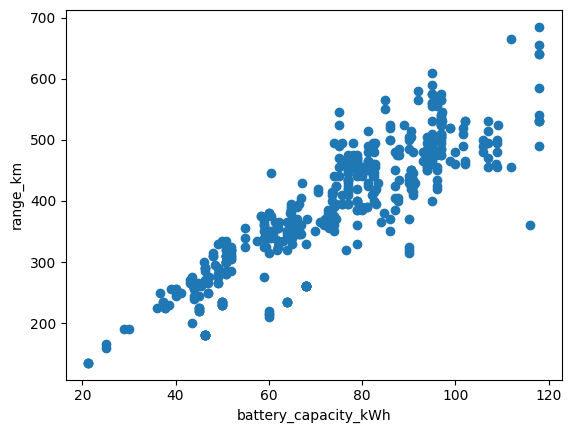

In [28]:
plt.xlabel("battery_capacity_kWh")
plt.ylabel("range_km")
plt.scatter(data['battery_capacity_kWh'], data[['range_km']])

In [21]:
X = data[['battery_capacity_kWh']]
y = data[['range_km']]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = linear_model.LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [22]:
predictions = model.predict(X_test)

results_df = pd.DataFrame({'Actual': y_test.squeeze(), 'Predicted': predictions.squeeze()})
print(results_df)

     Actual   Predicted
469     480  481.337312
33      495  485.335879
131     235  348.051721
72      415  430.244502
78      445  405.808810
..      ...         ...
140     390  392.480251
42      430  424.468793
248     220  263.637514
296     260  365.823133
291     245  259.194661

[96 rows x 2 columns]


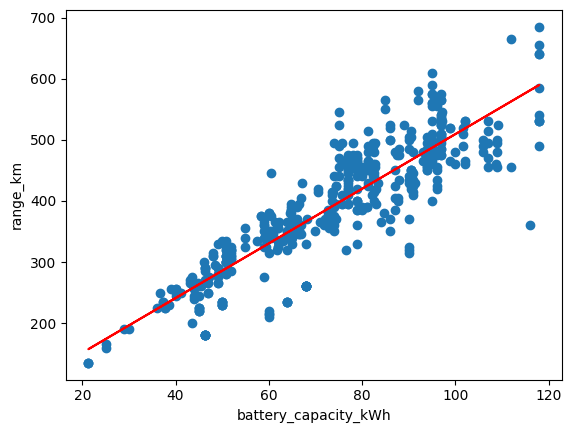

In [23]:
plt.xlabel("battery_capacity_kWh")
plt.ylabel("range_km")
plt.scatter(x, y)

plt.plot(df['battery_capacity_kWh'], slr.predict(df[['battery_capacity_kWh']]), color='red')

In [24]:
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("R-squared:", r2)

Mean Absolute Error: 37.45006663996845
Mean Squared Error: 2405.0086833855717
R-squared: 0.7727212970874994


In [29]:
# Save model

import pickle

pickle.dump(model, open("EVs Driving Range Prediction.pkl", "wb"))

print("Model saved successfully")

Model saved successfully
